# 🔋 Prédiction du State of Health (SoH) des batteries lithium-ion
## Modélisation LSTM — Pipeline complet

---

**Dataset :** NASA Battery Dataset (battery_health_dataset.csv)  
**Objectif :** Prédire le SoH (%) à partir de mesures électriques et thermiques  
**Framework :** TensorFlow / Keras  
**Architecture :** LSTM bidirectionnel à 2 couches  

---

### Pipeline officiel
```
Étape 1 — Analyse et vérification de la qualité des données
Étape 2 — Sélection des variables pertinentes
Étape 3 — Découpage des cycles en fenêtres temporelles
Étape 4 — Association de chaque fenêtre au SoH
Étape 5 — Séparation données train / test
Étape 6 — Apprentissage du modèle LSTM
Étape 7 — Prédiction du SoH sur données inconnues
Étape 8 — Évaluation des performances
```

---
## Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib

# Reproductibilité
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Style global des graphiques
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
})

print(f'TensorFlow : {tf.__version__}')


TensorFlow : 2.21.0
Répertoire : /Users/m12020/Downloads/PROJET_SoH_DEEP_LEARNING


---
## Étape 1 — Analyse et vérification de la qualité des données

In [2]:
df = pd.read_csv('battery_health_dataset.csv')

print('╔══════════════════════════════════════════╗')
print('║        APERÇU GÉNÉRAL DU DATASET         ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Lignes         : {df.shape[0]:<23}║')
print(f'║  Colonnes       : {df.shape[1]:<23}║')
print(f'║  Batteries      : {df["battery_id"].nunique():<23}║')
print(f'║  Cycles max     : {df["cycle_number"].max():<23}║')
print(f'║  Timesteps/cycle: {int(df.groupby(["battery_id","cycle_number"]).size().mean()):<23}║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║        APERÇU GÉNÉRAL DU DATASET         ║
╠══════════════════════════════════════════╣
║  Lignes         : 29180                  ║
║  Colonnes       : 7                      ║
║  Batteries      : 24                     ║
║  Cycles max     : 197                    ║
║  Timesteps/cycle: 20                     ║
╚══════════════════════════════════════════╝


In [3]:
# 1.1 Valeurs manquantes
print('=== 1.1 Valeurs manquantes ===')
missing = df.isnull().sum()
print(missing)
print(f'\n→ Total valeurs manquantes : {missing.sum()}')
if missing.sum() == 0:
    print('✅ Aucune valeur manquante')

=== 1.1 Valeurs manquantes ===
Voltage_measured        0
Current_measured        0
Temperature_measured    0
SoC                     0
cycle_number            0
battery_id              0
SoH                     0
dtype: int64

→ Total valeurs manquantes : 0
✅ Aucune valeur manquante


In [4]:
# 1.2 Statistiques descriptives
print('=== 1.2 Statistiques descriptives ===')
display(df.describe().round(4))

=== 1.2 Statistiques descriptives ===


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,SoH
count,29180.0000,29180.0000,29180.0000,29180.0000,29180.0000,29180.0000
mean,3.4565,-2.3272,34.9490,49.5761,53.5696,82.3476
std,0.2596,0.9771,10.8187,29.0869,45.5535,7.0410
min,2.7311,-4.0307,4.7234,1.5392,1.0000,70.0222
25%,3.3151,-2.0146,29.5913,23.3489,18.0000,76.1445
50%,3.4698,-2.0081,33.3234,48.5813,37.0000,82.9299
75%,3.6301,-1.9893,40.1775,73.9829,84.0000,88.1736
max,4.2308,-0.8903,66.6723,98.7569,197.0000,122.0116


In [5]:
# 1.3 Détection des outliers via IQR
print('=== 1.3 Détection des outliers (méthode IQR) ===')
NUMERIC_COLS = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'SoH']

outlier_report = {}
for col in NUMERIC_COLS:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    pct   = n_out / len(df) * 100
    outlier_report[col] = {'n': n_out, 'pct': pct, 'lb': lb, 'ub': ub}
    print(f'{col:<25} → {n_out:>5} outliers ({pct:.2f}%)  |  [{lb:.3f}, {ub:.3f}]')

# Note sur B0036
n_soh_above_100 = (df['SoH'] > 100).sum()
print(f'\n⚠️  SoH > 100% : {n_soh_above_100} mesures (batterie B0036 — anomalie de calibration conservée)')

=== 1.3 Détection des outliers (méthode IQR) ===
Voltage_measured          →   334 outliers (1.14%)  |  [2.843, 4.103]
Current_measured          → 12330 outliers (42.25%)  |  [-2.053, -1.951]
Temperature_measured      →  2695 outliers (9.24%)  |  [13.712, 56.057]
SoC                       →     0 outliers (0.00%)  |  [-52.602, 149.934]
SoH                       →    20 outliers (0.07%)  |  [58.101, 106.217]

⚠️  SoH > 100% : 140 mesures (batterie B0036 — anomalie de calibration conservée)


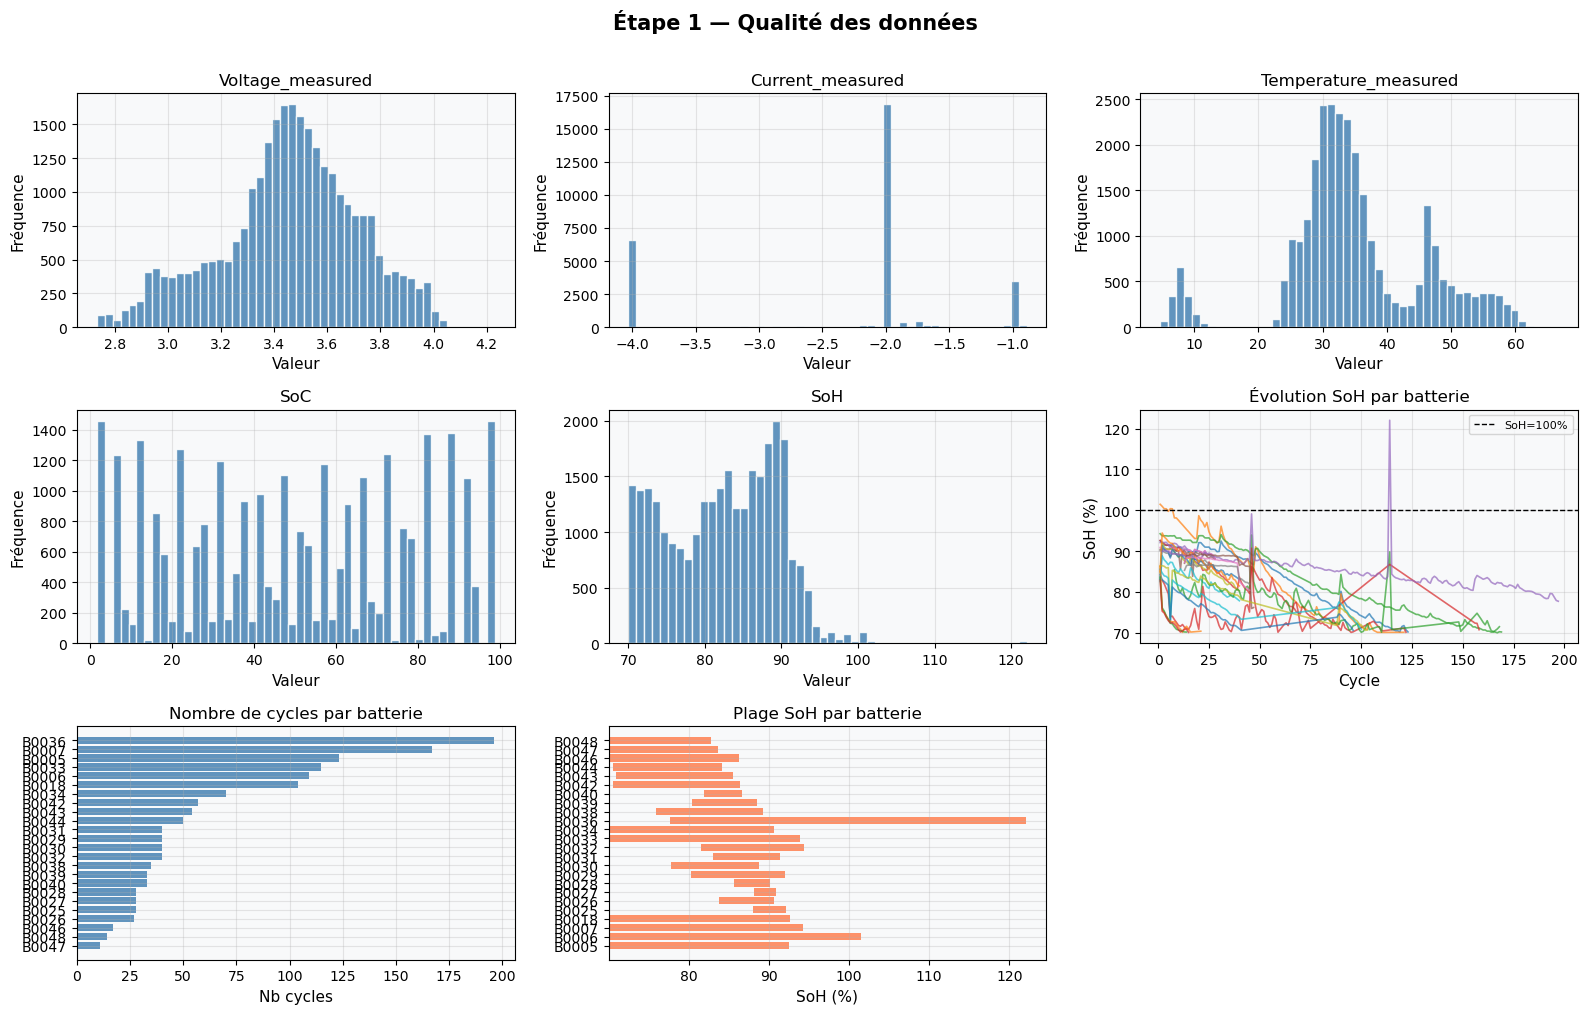

In [6]:
# 1.4 Visualisation : distributions et évolution du SoH
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Étape 1 — Qualité des données', fontsize=15, fontweight='bold', y=1.01)

# Distributions
for i, col in enumerate(NUMERIC_COLS):
    ax = fig.add_subplot(3, 3, i + 1)
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')

# Évolution SoH par batterie
ax = fig.add_subplot(3, 3, 6)
soh_cycle = df.groupby(['battery_id', 'cycle_number'])['SoH'].first().reset_index()
for bat in sorted(soh_cycle['battery_id'].unique()):
    sub = soh_cycle[soh_cycle['battery_id'] == bat]
    ax.plot(sub['cycle_number'], sub['SoH'], alpha=0.7, linewidth=1.2)
ax.axhline(100, color='black', linestyle='--', linewidth=1, label='SoH=100%')
ax.set_title('Évolution SoH par batterie')
ax.set_xlabel('Cycle')
ax.set_ylabel('SoH (%)')
ax.legend(fontsize=8)

# Cycles par batterie
ax = fig.add_subplot(3, 3, 7)
cycles_per_bat = df.groupby('battery_id')['cycle_number'].nunique().sort_values()
ax.barh(cycles_per_bat.index, cycles_per_bat.values, color='steelblue', alpha=0.85)
ax.set_title('Nombre de cycles par batterie')
ax.set_xlabel('Nb cycles')

# SoH range par batterie
ax = fig.add_subplot(3, 3, 8)
soh_range = df.groupby('battery_id')['SoH'].agg(['min', 'max'])
ax.barh(soh_range.index, soh_range['max'] - soh_range['min'],
        left=soh_range['min'], color='coral', alpha=0.85)
ax.set_title('Plage SoH par batterie')
ax.set_xlabel('SoH (%)')

plt.tight_layout()
plt.show()

---
## Étape 2 — Sélection des variables pertinentes

In [7]:
# 2.1 Corrélation de Pearson et Spearman avec le SoH
CANDIDATES = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_number']

print('=== 2.1 Corrélation avec le SoH ===')
print(f'{"Feature":<25} {"Pearson":>10} {"Spearman":>10} {"p-value":>12} {"Décision":>12}')
print('-' * 72)

selected_features = []
for feat in CANDIDATES:
    r_p, p_p = stats.pearsonr(df[feat],  df['SoH'])
    r_s, _   = stats.spearmanr(df[feat], df['SoH'])
    keep     = '✅ Gardée' if abs(r_p) > 0.1 or abs(r_s) > 0.1 else '❌ Exclue'
    if '✅' in keep:
        selected_features.append(feat)
    print(f'{feat:<25} {r_p:>10.4f} {r_s:>10.4f} {p_p:>12.2e} {keep:>12}')

=== 2.1 Corrélation avec le SoH ===
Feature                      Pearson   Spearman      p-value     Décision
------------------------------------------------------------------------
Voltage_measured              0.2661     0.2510     0.00e+00     ✅ Gardée
Current_measured              0.1171     0.0928     1.55e-89     ✅ Gardée
Temperature_measured          0.2416     0.1681     0.00e+00     ✅ Gardée
SoC                           0.0051     0.0078     3.84e-01     ❌ Exclue
cycle_number                 -0.5049    -0.5463     0.00e+00     ✅ Gardée


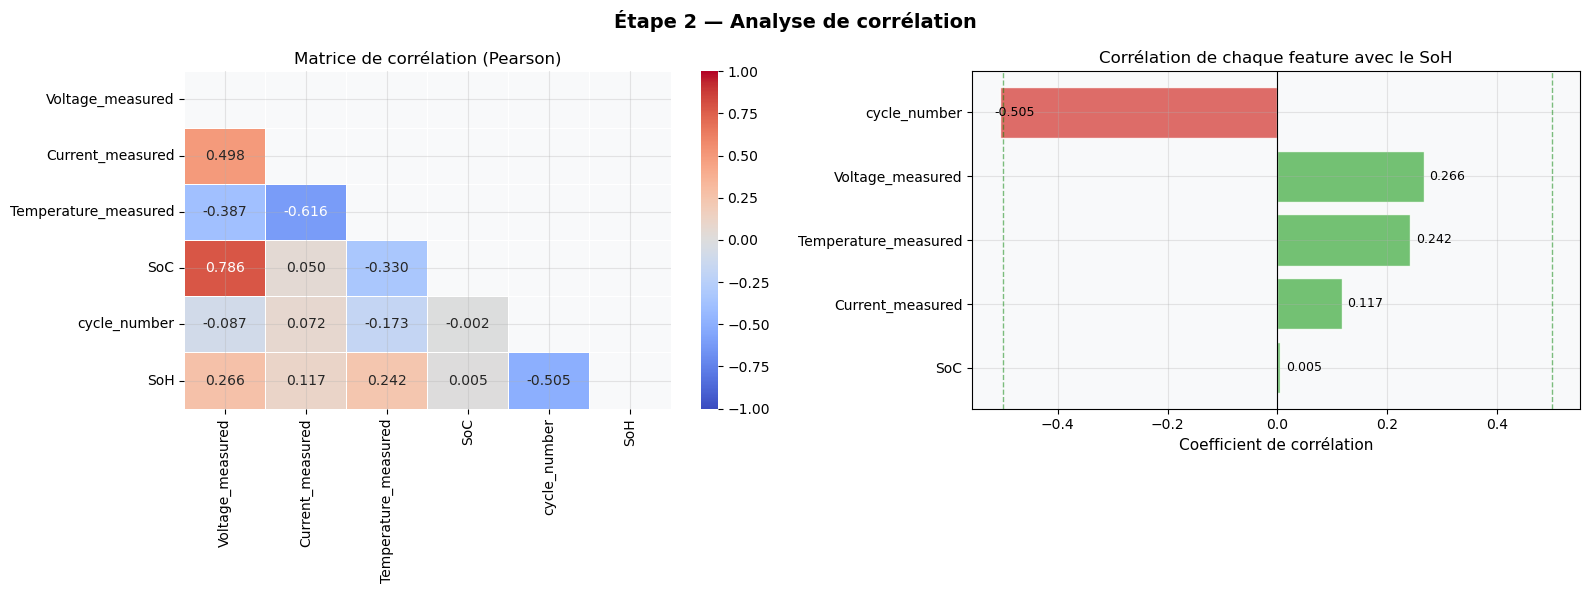

In [8]:
# 2.2 Matrice de corrélation complète
corr = df[CANDIDATES + ['SoH']].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Étape 2 — Analyse de corrélation', fontsize=14, fontweight='bold')

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matrice de corrélation (Pearson)')

# Corrélation vs SoH
corr_soh = corr['SoH'].drop('SoH').sort_values(key=abs, ascending=True)
colors_bar = ['#d9534f' if v < 0 else '#5cb85c' for v in corr_soh]
axes[1].barh(corr_soh.index, corr_soh.values, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.5,  color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[1].axvline(-0.5, color='green', linestyle='--', alpha=0.5, linewidth=1)
axes[1].set_title('Corrélation de chaque feature avec le SoH')
axes[1].set_xlabel('Coefficient de corrélation')
for i, (val, feat) in enumerate(zip(corr_soh.values, corr_soh.index)):
    axes[1].text(val + 0.01 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# 2.3 Normalisation du cycle_number par batterie
# Justification : B0047 a 11 cycles, B0036 en a 196.
# Un scaler global écrase les batteries à faible nombre de cycles.
# → On normalise par batterie pour que chaque cycle ∈ [0, 1] indépendamment.

df['cycle_norm'] = df.groupby('battery_id')['cycle_number'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# Features finales retenues
FEATURES = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_norm']
TARGET   = 'SoH'

print('=== Features sélectionnées ===')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i}. {f}')
print(f'\nCible : {TARGET}')
print('\n✅ cycle_number remplacé par cycle_norm (normalisé par batterie)')

# Vérification
check = df.groupby('battery_id')['cycle_norm'].agg(['min','max'])
assert (check['min'] == 0.0).all(), 'Erreur normalisation'
print('✅ Vérification cycle_norm : OK — range [0.0, 1.0] pour toutes les batteries')

=== Features sélectionnées ===
  1. Voltage_measured
  2. Current_measured
  3. Temperature_measured
  4. SoC
  5. cycle_norm

Cible : SoH

✅ cycle_number remplacé par cycle_norm (normalisé par batterie)
✅ Vérification cycle_norm : OK — range [0.0, 1.0] pour toutes les batteries


---
## Étape 3 — Découpage des cycles en fenêtres temporelles

Chaque cycle contient **20 timesteps fixes** (mesures électriques et thermiques).  
On utilise une **fenêtre glissante de 20 timesteps** (= 1 cycle complet) avec un stride de 1.  
→ Chaque fenêtre représente la dynamique complète d'un cycle de décharge.

In [10]:
WINDOW_SIZE      = 20   # 1 cycle complet
STRIDE           = 1
TIMESTEPS_CYCLE  = 20
N_FEAT           = len(FEATURES)

all_sequences = []
all_targets   = []
all_batteries = []
all_cycles    = []

for bat_id, bat_df in df.groupby('battery_id'):
    bat_df = bat_df.sort_values('cycle_number').reset_index(drop=True)
    data   = bat_df[FEATURES].values   # (N_mesures, 5)
    labels = bat_df[TARGET].values     # (N_mesures,)
    cycles = bat_df['cycle_number'].values

    for start in range(0, len(data) - WINDOW_SIZE + 1, STRIDE):
        end = start + WINDOW_SIZE
        all_sequences.append(data[start:end])      # (20, 5)
        all_targets.append(labels[end - 1])        # SoH du dernier timestep
        all_batteries.append(bat_id)
        all_cycles.append(cycles[end - 1])

all_sequences = np.array(all_sequences, dtype=np.float32)  # (N, 20, 5)
all_targets   = np.array(all_targets,   dtype=np.float32)  # (N,)
all_batteries = np.array(all_batteries)
all_cycles    = np.array(all_cycles)

print(f'✅ Fenêtres construites')
print(f'   Nombre total : {all_sequences.shape[0]}')
print(f'   Shape        : {all_sequences.shape}  → (N_fenêtres, timesteps, features)')
print(f'   SoH — min: {all_targets.min():.2f}%  max: {all_targets.max():.2f}%  moy: {all_targets.mean():.2f}%')

✅ Fenêtres construites
   Nombre total : 28724
   Shape        : (28724, 20, 5)  → (N_fenêtres, timesteps, features)
   SoH — min: 70.02%  max: 122.01%  moy: 82.26%


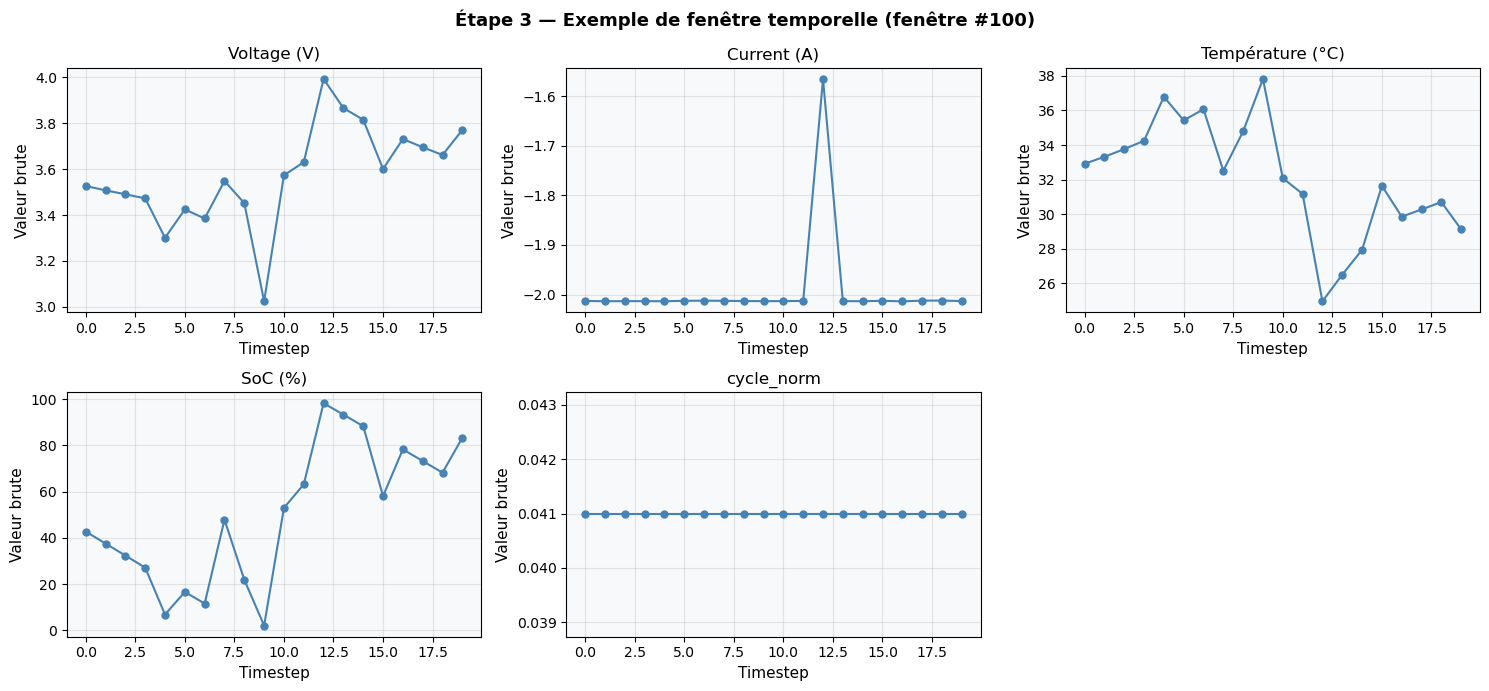

In [11]:
# Visualisation d'une fenêtre type
sample_win = all_sequences[100]  # fenêtre #100
feat_labels = ['Voltage (V)', 'Current (A)', 'Température (°C)', 'SoC (%)', 'cycle_norm']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Étape 3 — Exemple de fenêtre temporelle (fenêtre #100)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(range(N_FEAT), feat_labels)):
    axes[i].plot(sample_win[:, feat], 'o-', color='steelblue', markersize=5, linewidth=1.5)
    axes[i].set_title(label)
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('Valeur brute')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

---
## Étape 4 — Association de chaque fenêtre au SoH

Le SoH est **constant sur l'ensemble d'un cycle** (c'est une propriété globale de la batterie).  
→ La cible associée à chaque fenêtre = SoH du **dernier timestep** de la fenêtre.

Std du SoH à l'intérieur de chaque cycle :
  Max : 0.000000  (doit être ≈ 0)
  Moy : 0.000000
✅ SoH constant par cycle — association fenêtre→SoH valide


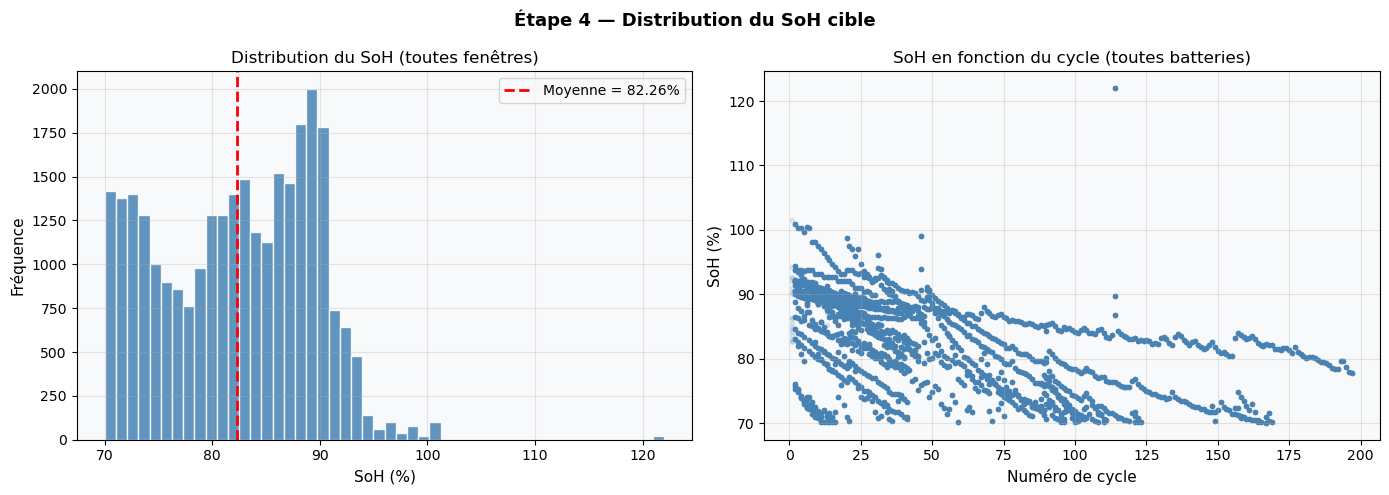

In [12]:
# Vérification : le SoH est bien constant sur chaque cycle
soh_std_per_cycle = df.groupby(['battery_id', 'cycle_number'])['SoH'].std().fillna(0)
print(f'Std du SoH à l\'intérieur de chaque cycle :')
print(f'  Max : {soh_std_per_cycle.max():.6f}  (doit être ≈ 0)')
print(f'  Moy : {soh_std_per_cycle.mean():.6f}')
print(f'✅ SoH constant par cycle — association fenêtre→SoH valide')

# Distribution des targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Étape 4 — Distribution du SoH cible', fontsize=13, fontweight='bold')

axes[0].hist(all_targets, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(all_targets.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Moyenne = {all_targets.mean():.2f}%')
axes[0].set_xlabel('SoH (%)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution du SoH (toutes fenêtres)')
axes[0].legend()

axes[1].scatter(all_cycles, all_targets, alpha=0.15, s=8, color='steelblue')
axes[1].set_xlabel('Numéro de cycle')
axes[1].set_ylabel('SoH (%)')
axes[1].set_title('SoH en fonction du cycle (toutes batteries)')

plt.tight_layout()
plt.show()

---
## Étape 5 — Séparation données train / val / test

**Stratégie : split stratifié par bins de SoH**

Le SoH est divisé en 5 plages égales (percentiles).  
Dans chaque plage : 70% train — 15% val — 15% test.  
→ Les 3 splits couvrent toute la gamme de dégradation (70% à 122%).

In [13]:
N_BINS     = 5
bins       = np.percentile(all_targets, np.linspace(0, 100, N_BINS + 1))
bin_labels = np.digitize(all_targets, bins[1:-1])

train_idx, val_idx, test_idx = [], [], []

print('=== Répartition par bin ===')
print(f'{"Bin":<6} {"Plage SoH":<20} {"Total":>7} {"Train":>7} {"Val":>7} {"Test":>7}')
print('-' * 57)

for b in range(N_BINS):
    idx  = np.where(bin_labels == b)[0]
    np.random.shuffle(idx)
    n    = len(idx)
    t1   = int(0.70 * n)
    t2   = int(0.85 * n)
    train_idx.extend(idx[:t1])
    val_idx.extend(idx[t1:t2])
    test_idx.extend(idx[t2:])
    soh_min = all_targets[idx].min()
    soh_max = all_targets[idx].max()
    print(f'{b:<6} [{soh_min:.1f}% – {soh_max:.1f}%]    {n:>7} {t1:>7} {t2-t1:>7} {n-t2:>7}')

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

print('-' * 57)
print(f'{"TOTAL":<6} {"":20} {len(all_targets):>7} {len(train_idx):>7} {len(val_idx):>7} {len(test_idx):>7}')
print(f'\nRatio : Train {len(train_idx)/len(all_targets)*100:.1f}% | Val {len(val_idx)/len(all_targets)*100:.1f}% | Test {len(test_idx)/len(all_targets)*100:.1f}%')

=== Répartition par bin ===
Bin    Plage SoH              Total   Train     Val    Test
---------------------------------------------------------
0      [70.0% – 74.4%]       5740    4017     862     861
1      [74.4% – 80.6%]       5740    4017     862     861
2      [80.7% – 85.2%]       5748    4023     862     863
3      [85.2% – 88.9%]       5747    4022     862     863
4      [88.9% – 122.0%]       5749    4024     862     863
---------------------------------------------------------
TOTAL                         28724   20103    4310    4311

Ratio : Train 70.0% | Val 15.0% | Test 15.0%


X_train : (20103, 20, 5)  y_train : (20103,)
X_val   : (4310, 20, 5)    y_val   : (4310,)
X_test  : (4311, 20, 5)   y_test  : (4311,)


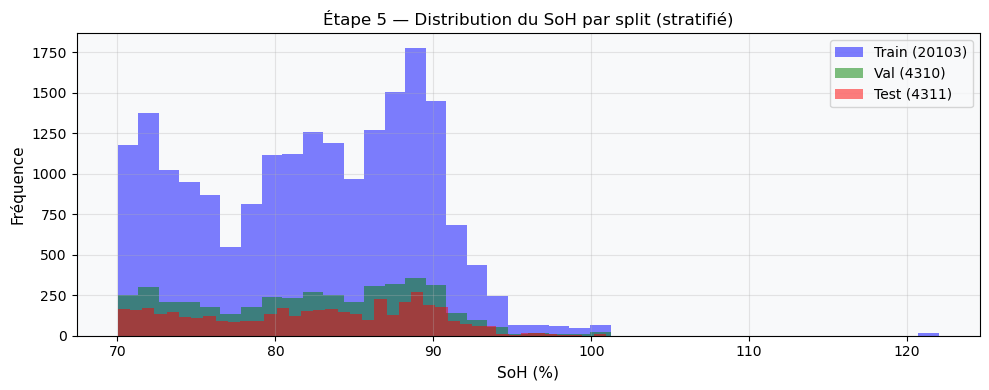

In [14]:
# Normalisation — fit sur train uniquement
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

train_flat = all_sequences[train_idx].reshape(-1, N_FEAT)
scaler_X.fit(train_flat)
scaler_y.fit(all_targets[train_idx].reshape(-1, 1))

def transform_split(idx):
    N   = len(idx)
    X   = all_sequences[idx]
    X_n = scaler_X.transform(X.reshape(-1, N_FEAT)).reshape(N, WINDOW_SIZE, N_FEAT)
    y_n = scaler_y.transform(all_targets[idx].reshape(-1, 1)).flatten()
    return X_n.astype(np.float32), y_n.astype(np.float32)

X_train, y_train = transform_split(train_idx)
X_val,   y_val   = transform_split(val_idx)
X_test,  y_test  = transform_split(test_idx)

print(f'X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}    y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')

# Vérification distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_targets[train_idx], bins=40, alpha=0.5, color='blue',  label=f'Train ({len(train_idx)})')
ax.hist(all_targets[val_idx],   bins=40, alpha=0.5, color='green', label=f'Val ({len(val_idx)})')
ax.hist(all_targets[test_idx],  bins=40, alpha=0.5, color='red',   label=f'Test ({len(test_idx)})')
ax.set_xlabel('SoH (%)')
ax.set_ylabel('Fréquence')
ax.set_title('Étape 5 — Distribution du SoH par split (stratifié)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 6 — Apprentissage du modèle LSTM

**Architecture :**
```
Input  : (batch, 20, 5)
LSTM(128, return_sequences=True) → Dropout(0.3) → BatchNorm
LSTM(64,  return_sequences=False) → Dropout(0.3) → BatchNorm
Dense(32, relu) → Dropout(0.2)
Dense(1)   ← sortie SoH normalisé
```
**Loss :** Huber (δ=0.5) — robuste aux outliers, évite le collapse vers la moyenne  
**Optimizer :** Adam (lr=1e-3) avec ReduceLROnPlateau

In [15]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

def build_lstm_model(window_size, n_features, units_1=128, units_2=64, dropout=0.3, lr=1e-3):
    model = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=(window_size, n_features)),
        Dropout(dropout),
        BatchNormalization(),

        LSTM(units_2, return_sequences=False),
        Dropout(dropout),
        BatchNormalization(),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1)
    ], name='LSTM_SoH_Predictor')

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.Huber(delta=0.5),
        metrics=['mae']
    )
    return model

model = build_lstm_model(WINDOW_SIZE, N_FEAT)
model.summary()

total_params = model.count_params()
print(f'\nLR initial    : {model.optimizer.learning_rate.numpy()}')
print(f'Total paramètres : {total_params:,}')

Model: "LSTM_SoH_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,897 (472.25 KB)

 Trainable params: 120,513 (470.75 KB)

 Non-trainable params: 384 (1.50 KB)


LR initial    : 0.0010000000474974513
Total paramètres : 120,897


In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

print('🚀 Début de l\'entraînement...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print(f'✅ Entraînement terminé — {len(history.history["loss"])} epochs')

🚀 Début de l'entraînement...
Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - loss: 0.0773 - mae: 0.3110 - val_loss: 0.0060 - val_mae: 0.0919 - learning_rate: 0.0010
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0125 - mae: 0.1231 - val_loss: 0.0054 - val_mae: 0.0835 - learning_rate: 0.0010
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.0070 - mae: 0.0944 - val_loss: 0.0044 - val_mae: 0.0761 - learning_rate: 0.0010
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0055 - mae: 0.0840 - val_loss: 0.0037 - val_mae: 0.0716 - learning_rate: 0.0010
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0046 - mae: 0.0774 - val_loss: 0.0037 - val_mae: 0.0711 - learning_rate: 0.0010
Epoch 6/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0042 - mae: 0.0733 - val_loss: 0.0029 - val_mae: 0.0605 - learning_rate: 0.0010
Epoch 7/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.0039 - mae: 0.0707 - val_loss: 0.002

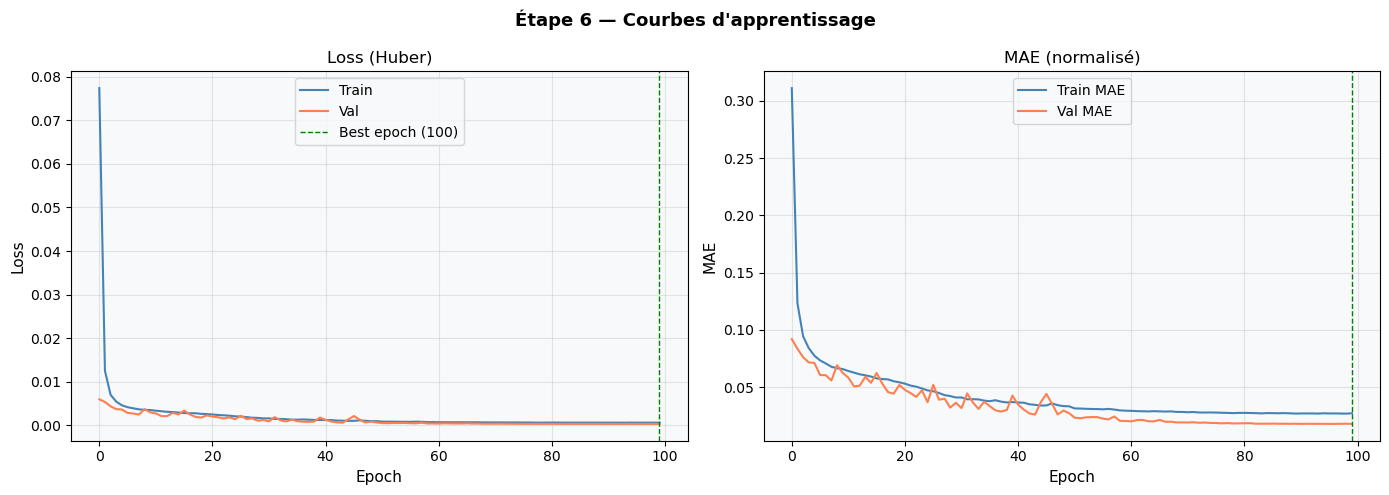

Best epoch    : 100
Best val_loss : 0.000359


In [17]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Étape 6 — Courbes d\'apprentissage', fontsize=13, fontweight='bold')

best_epoch = np.argmin(history.history['val_loss'])

axes[0].plot(history.history['loss'],     label='Train', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   color='coral',     linewidth=1.5)
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1,
                label=f'Best epoch ({best_epoch+1})')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='coral',     linewidth=1.5)
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1)
axes[1].set_title('MAE (normalisé)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best epoch    : {best_epoch + 1}')
print(f'Best val_loss : {min(history.history["val_loss"]):.6f}')

---
## Étape 7 — Prédiction du SoH sur données inconnues

In [18]:
# Prédictions sur le jeu de test (données inconnues)
print('🔍 Prédiction sur le jeu de test...')
y_pred_norm = model.predict(X_test, verbose=0).flatten()

# Dénormalisation
y_pred = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f'✅ {len(y_pred)} prédictions générées')

# Affichage des 10 premières prédictions
print('\nExemples de prédictions (10 premières) :')
print(f'{"#":<5} {"SoH réel":>12} {"SoH prédit":>12} {"Erreur abs":>12}')
print('-' * 44)
for i in range(10):
    err = abs(y_true[i] - y_pred[i])
    print(f'{i+1:<5} {y_true[i]:>12.3f} {y_pred[i]:>12.3f} {err:>12.3f}')

🔍 Prédiction sur le jeu de test...
✅ 4311 prédictions générées

Exemples de prédictions (10 premières) :
#         SoH réel   SoH prédit   Erreur abs
--------------------------------------------
1           73.989       73.235        0.754
2           71.785       77.281        5.496
3           72.634       72.053        0.581
4           70.937       70.816        0.121
5           73.827       73.837        0.010
6           70.508       71.219        0.711
7           70.853       71.727        0.875
8           71.419       72.342        0.923
9           72.215       72.739        0.524
10          74.077       72.417        1.659


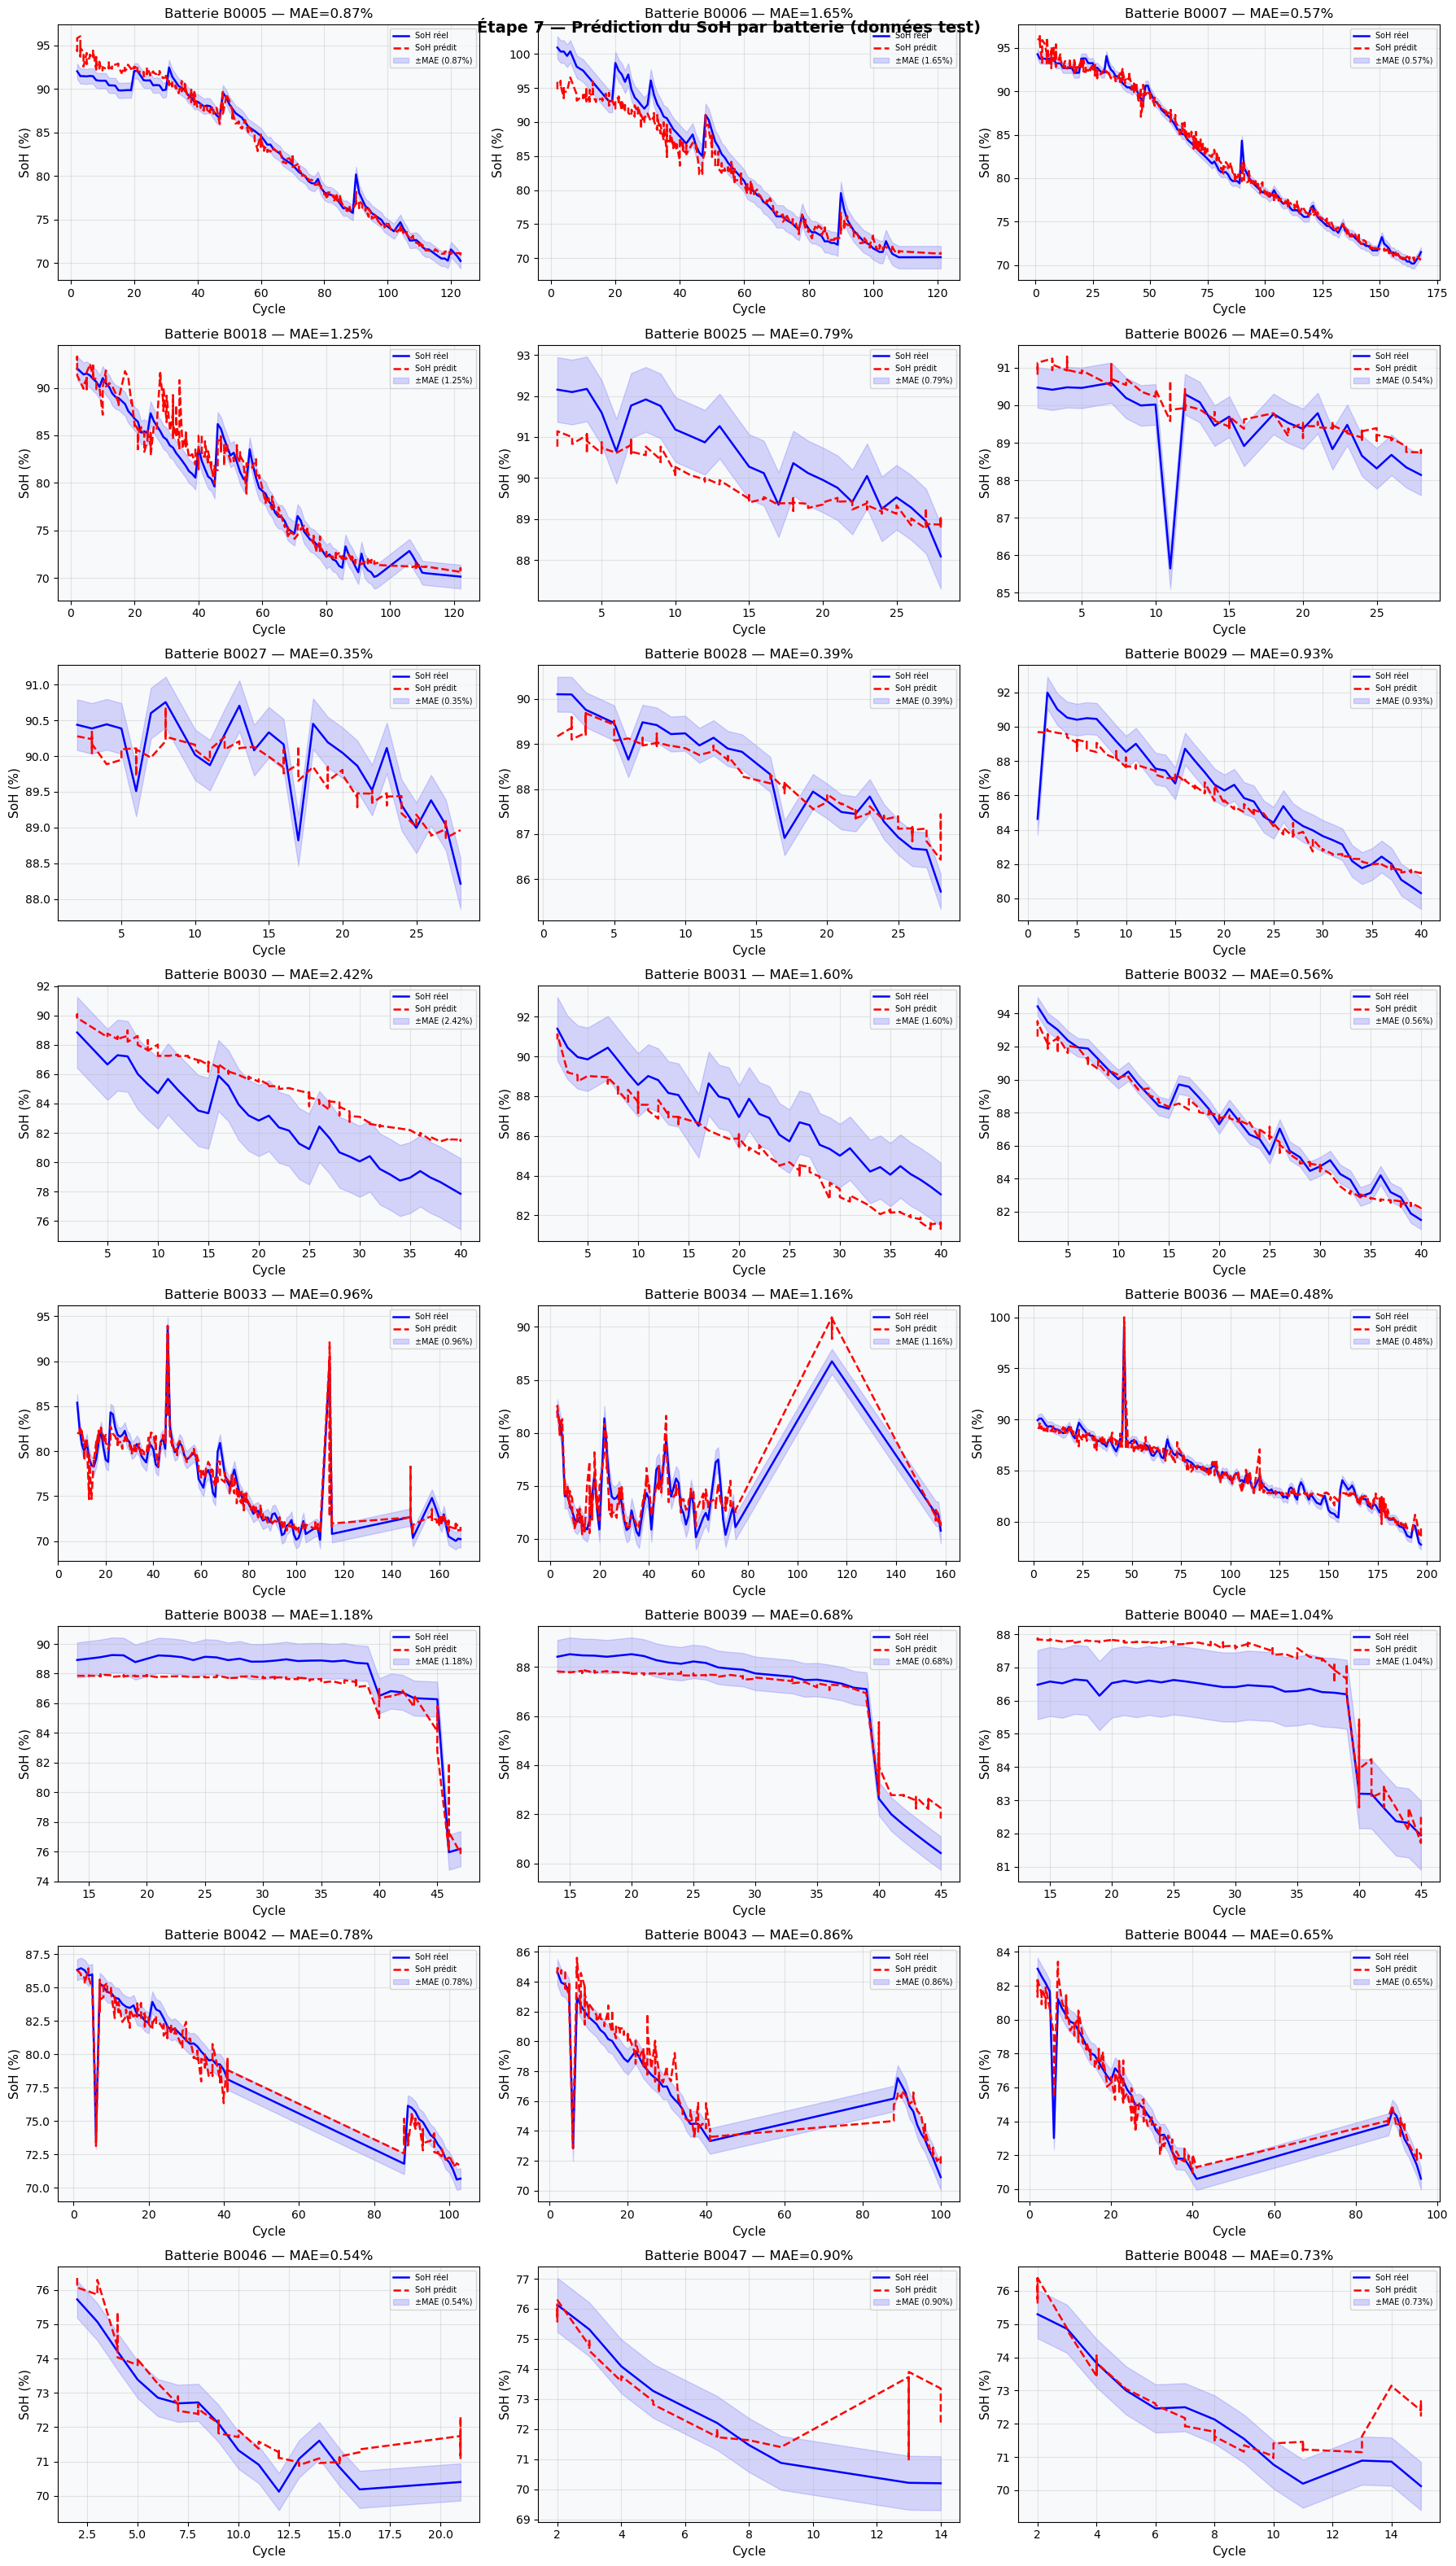

In [19]:
# Suivi par batterie — prédiction cycle par cycle
test_batteries   = all_batteries[test_idx]
test_cycles_arr  = all_cycles[test_idx]
unique_test_bats = np.unique(test_batteries)

ncols = 3
nrows = int(np.ceil(len(unique_test_bats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
fig.suptitle('Étape 7 — Prédiction du SoH par batterie (données test)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, bat in enumerate(unique_test_bats):
    mask       = test_batteries == bat
    cyc        = test_cycles_arr[mask]
    yt         = y_true[mask]
    yp         = y_pred[mask]
    order      = np.argsort(cyc)
    cyc, yt, yp = cyc[order], yt[order], yp[order]
    mae_bat    = mean_absolute_error(yt, yp)

    axes[i].plot(cyc, yt, 'b-',  linewidth=1.8, label='SoH réel')
    axes[i].plot(cyc, yp, 'r--', linewidth=1.8, label='SoH prédit')
    axes[i].fill_between(cyc, yt - mae_bat, yt + mae_bat,
                         alpha=0.15, color='blue', label=f'±MAE ({mae_bat:.2f}%)')
    axes[i].set_title(f'Batterie {bat} — MAE={mae_bat:.2f}%')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('SoH (%)')
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## Étape 8 — Évaluation des performances

In [20]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('╔══════════════════════════════════════════════╗')
print('║       📊 RÉSULTATS — JEU DE TEST             ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  MAE   : {mae:.4f} %  (erreur absolue moyenne)   ║')
print(f'║  RMSE  : {rmse:.4f} %  (erreur quadratique moy.) ║')
print(f'║  MAPE  : {mape:.2f} %    (erreur relative moy.)   ║')
print(f'║  R²    : {r2:.4f}    (variance expliquée)       ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Std y_pred : {y_pred.std():.4f}  Std y_true : {y_true.std():.4f}    ║')
print(f'║  Ratio std  : {y_pred.std()/y_true.std():.3f}  (idéal = 1.0)          ║')
print(f'║  Biais      : {(y_pred.mean()-y_true.mean()):+.4f} %                         ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║       📊 RÉSULTATS — JEU DE TEST             ║
╠══════════════════════════════════════════════╣
║  MAE   : 0.9040 %  (erreur absolue moyenne)   ║
║  RMSE  : 1.3269 %  (erreur quadratique moy.) ║
║  MAPE  : 1.09 %    (erreur relative moy.)   ║
║  R²    : 0.9640    (variance expliquée)       ║
╠══════════════════════════════════════════════╣
║  Std y_pred : 6.7714  Std y_true : 6.9901    ║
║  Ratio std  : 0.969  (idéal = 1.0)          ║
║  Biais      : +0.0216 %                         ║
╚══════════════════════════════════════════════╝


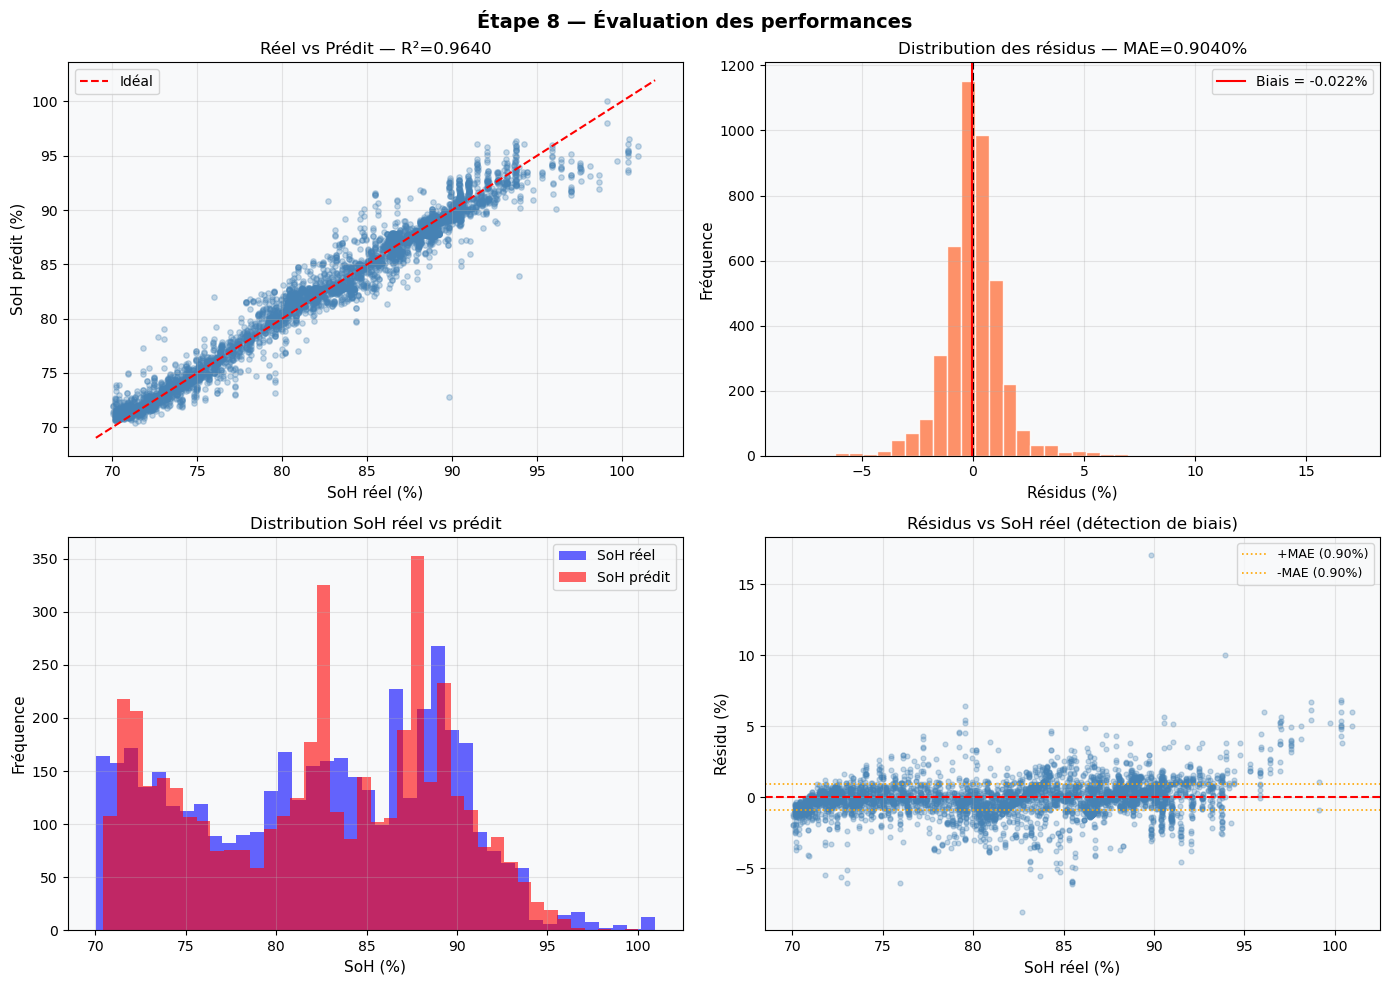

In [21]:
# Graphiques d'évaluation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Étape 8 — Évaluation des performances', fontsize=14, fontweight='bold')

# 1. Scatter réel vs prédit
axes[0, 0].scatter(y_true, y_pred, alpha=0.3, color='steelblue', s=15)
lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
axes[0, 0].plot(lims, lims, 'r--', linewidth=1.5, label='Idéal')
axes[0, 0].set_xlabel('SoH réel (%)')
axes[0, 0].set_ylabel('SoH prédit (%)')
axes[0, 0].set_title(f'Réel vs Prédit — R²={r2:.4f}')
axes[0, 0].legend()

# 2. Résidus
residuals = y_true - y_pred
axes[0, 1].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.5,
                   label=f'Biais = {residuals.mean():+.3f}%')
axes[0, 1].set_xlabel('Résidus (%)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title(f'Distribution des résidus — MAE={mae:.4f}%')
axes[0, 1].legend()

# 3. Distribution réel vs prédit
axes[1, 0].hist(y_true, bins=40, alpha=0.6, color='blue',  label='SoH réel')
axes[1, 0].hist(y_pred, bins=40, alpha=0.6, color='red',   label='SoH prédit')
axes[1, 0].set_xlabel('SoH (%)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution SoH réel vs prédit')
axes[1, 0].legend()

# 4. Résidus vs SoH réel
axes[1, 1].scatter(y_true, residuals, alpha=0.3, color='steelblue', s=12)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].axhline(mae,  color='orange', linestyle=':', linewidth=1.2, label=f'+MAE ({mae:.2f}%)')
axes[1, 1].axhline(-mae, color='orange', linestyle=':', linewidth=1.2, label=f'-MAE ({mae:.2f}%)')
axes[1, 1].set_xlabel('SoH réel (%)')
axes[1, 1].set_ylabel('Résidu (%)')
axes[1, 1].set_title('Résidus vs SoH réel (détection de biais)')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Sauvegarde du modèle final

In [22]:
model.save('battery_soh_lstm_FINAL.keras')
joblib.dump(scaler_X, 'scaler_X_FINAL.pkl')
joblib.dump(scaler_y, 'scaler_y_FINAL.pkl')

print('✅ Modèle sauvegardé   : battery_soh_lstm_FINAL.keras')
print('✅ Scalers sauvegardés : scaler_X_FINAL.pkl | scaler_y_FINAL.pkl')

print('\n=== Récapitulatif final ===')
print(f'  Architecture : LSTM(128) → LSTM(64) → Dense(32) → Dense(1)')
print(f'  Features     : {FEATURES}')
print(f'  Window size  : {WINDOW_SIZE} timesteps (1 cycle complet)')
print(f'  Loss         : Huber (delta=0.5)')
print(f'  MAE test     : {mae:.4f} %')
print(f'  R² test      : {r2:.4f}')

✅ Modèle sauvegardé   : battery_soh_lstm_FINAL.keras
✅ Scalers sauvegardés : scaler_X_FINAL.pkl | scaler_y_FINAL.pkl

=== Récapitulatif final ===
  Architecture : LSTM(128) → LSTM(64) → Dense(32) → Dense(1)
  Features     : ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'cycle_norm']
  Window size  : 20 timesteps (1 cycle complet)
  Loss         : Huber (delta=0.5)
  MAE test     : 0.9040 %
  R² test      : 0.9640
